In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px

### Timely Care - Hospital Data Inspection and Cleaning

In [79]:
timely_care_hospital = pd.read_csv("Data/Timely_and_Effective_Care-Hospital.csv")
timely_care_state = pd.read_csv("Data/Timely_and_Effective_Care-State.csv")

C:\Users\bhoom\AppData\Local\Temp\ipykernel_35424\2363500569.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  timely_care_hospital = pd.read_csv("Data/Timely_and_Effective_Care-Hospital.csv")


In [80]:
timely_care_hospital["Score"].unique()

array(['very high', 'Not Available', '93', '214', '212', '3', '82', '62',
       '14', '61', '67', '96', '76', '95', '97', '99', '100', '59', '146',
       '143', '242', '332', '42', '98', '15', '73', '84', '90', '83',
       'high', '64', '158', '147', '218', '328', '1', '81', '52', '70',
       '74', '91', '94', 'low', '29', '137', '130', '295', '87', '33',
       '79', '168', '371', '71', '13', '78', '80', '85', '88', 'medium',
       '69', '174', '164', '346', '292', '2', '11', '75', '180', '182',
       '17', '66', '189', '188', '60', '92', '53', '152', '148', '279',
       '260', '77', '63', '72', '127', '123', '274', '0', '225', '220',
       '280', '25', '51', '9', '31', '139', '138', '136', '185', '10',
       '205', '200', '303', '5', '8', '219', '211', '399', '544', '12',
       '47', '105', '104', '111', '6', '348', '172', '324', '347', '249',
       '238', '300', '48', '19', '204', '201', '302', '16', '40', '35',
       '86', '106', '4', '124', '113', '316', '22', '155', '

In [81]:
TCH_clean = timely_care_hospital[timely_care_hospital['Score'] != 'Not Available']
TCH_clean = TCH_clean[TCH_clean['Score'] != 'very high']

In [82]:
timely_care_state.head()

,State,Condition,Measure ID,Measure Name,Score,Footnote,Start Date,End Date
0,AK,Healthcare Personnel Vaccination,IMM_3,Healthcare workers given influenza vaccination...,74,NaN,10/01/2024,03/31/2025
1,AK,Emergency Department,OP_18a,Average (median) time all patients spent in th...,143,NaN,10/01/2024,09/30/2025
2,AK,Emergency Department,OP_18a_HIGH_MIN,Average (median) time all patients spent in th...,156,NaN,10/01/2024,09/30/2025
3,AK,Emergency Department,OP_18a_LOW_MIN,Average (median) time all patients spent in th...,136,NaN,10/01/2024,09/30/2025
4,AK,Emergency Department,OP_18a_MEDIUM_MIN,Average (median) time all patients spent in th...,152,NaN,10/01/2024,09/30/2025


In [83]:
timely_care_state["Score"].unique();

In [84]:
TCS_clean = timely_care_state[timely_care_state['Score'] != 'Not Available'].copy()
TCS_clean['Score'] = pd.to_numeric(TCS_clean['Score'])

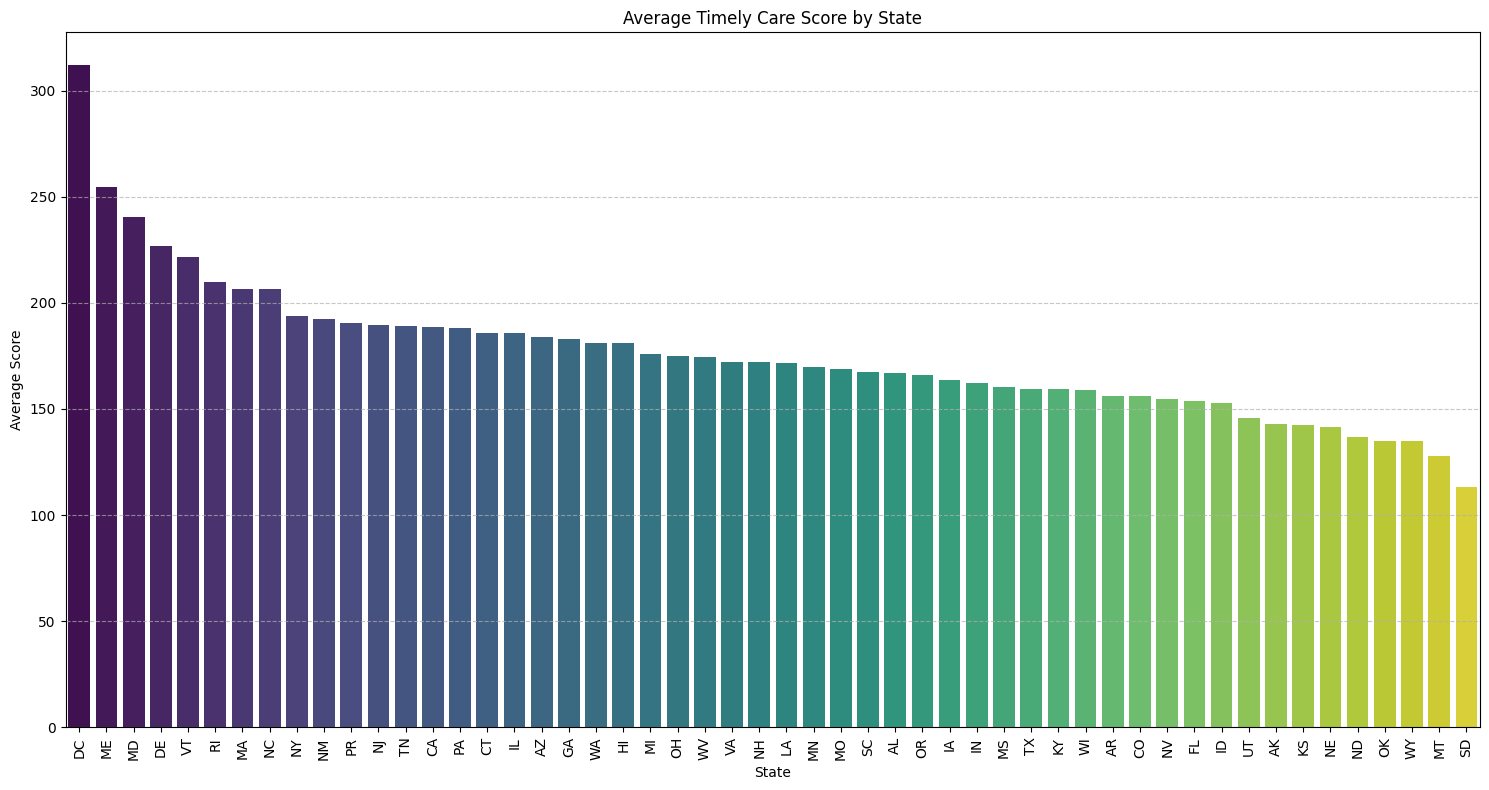

In [85]:
# Calculate the average score per state
state_avg_score = TCS_clean.groupby('State')['Score'].mean().reset_index()

# Sort by score for better visualization
state_avg_score = state_avg_score.sort_values(by='Score', ascending=False)

# Create the bar plot
fig = plt.figure(figsize=(15, 8))
sns.barplot(x='State', y='Score', data=state_avg_score, palette='viridis', hue='State', legend=False)
plt.title('Average Timely Care Score by State')
plt.xlabel('State')
plt.ylabel('Average Score')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyzing Hospital Performance by State (Complications & Deaths)

### Complications and Deaths - Hospital Data Inspection and Cleaning

In [86]:
death_comp_hospital = pd.read_csv("Data/Complications_and_Deaths-Hospital.csv")
death_comp_state = pd.read_csv("Data/Complications_and_Deaths-State.csv")

In [87]:
death_comp_hospital.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,33,3.8,2.4,6.0,NaN,04/01/2023,03/31/2025
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,4972,4.4,3.9,5.0,NaN,07/01/2024,06/30/2025
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,234,13.5,10.9,16.6,NaN,07/01/2022,06/30/2025
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,127,3.2,1.7,6.3,NaN,07/01/2022,06/30/2025
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,116,9.1,6.2,13.2,NaN,07/01/2022,06/30/2025


In [88]:
death_comp_hospital["Score"].unique()

scores = death_comp_hospital["Score"]
non_numeric = scores[pd.to_numeric(scores, errors="coerce").isna()].unique()
print(non_numeric)

['Not Available']


In [89]:
DCH_clean = death_comp_hospital[death_comp_hospital['Score'] != 'Not Available'].copy()

In [90]:
DCH_clean['Score'] = pd.to_numeric(DCH_clean['Score'], errors='coerce')
DCH_clean['Lower Estimate'] = pd.to_numeric(DCH_clean['Lower Estimate'], errors='coerce')
DCH_clean['Higher Estimate'] = pd.to_numeric(DCH_clean['Higher Estimate'], errors='coerce')

# Drop rows where critical numeric information is missing
DCH_clean = DCH_clean.dropna(subset=['Score'])

print("Data cleaning successful. Summary statistics:")
print(DCH_clean.describe())
display(DCH_clean.head())

Data cleaning successful. Summary statistics:
           ZIP Code         Score  Lower Estimate  Higher Estimate
count  52392.000000  52392.000000    52392.000000     52392.000000
mean   51769.895499     10.037684        6.450614        14.154836
std    28018.837687     29.038550       20.996007        37.275147
min      603.000000      0.050000        0.000000         0.220000
25%    29902.000000      1.060000        0.110000         2.050000
50%    48910.000000      3.430000        1.070000         5.100000
75%    76104.000000      9.500000        5.800000        14.655000
max    99901.000000    259.010000      209.320000       310.470000


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,No Different Than the National Rate,33,3.8,2.4,6.0,NaN,04/01/2023,03/31/2025
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,No Different Than the National Rate,4972,4.4,3.9,5.0,NaN,07/01/2024,06/30/2025
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_AMI,Death rate for heart attack patients,No Different Than the National Rate,234,13.5,10.9,16.6,NaN,07/01/2022,06/30/2025
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_CABG,Death rate for CABG surgery patients,No Different Than the National Rate,127,3.2,1.7,6.3,NaN,07/01/2022,06/30/2025
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,MORT_30_COPD,Death rate for COPD patients,No Different Than the National Rate,116,9.1,6.2,13.2,NaN,07/01/2022,06/30/2025


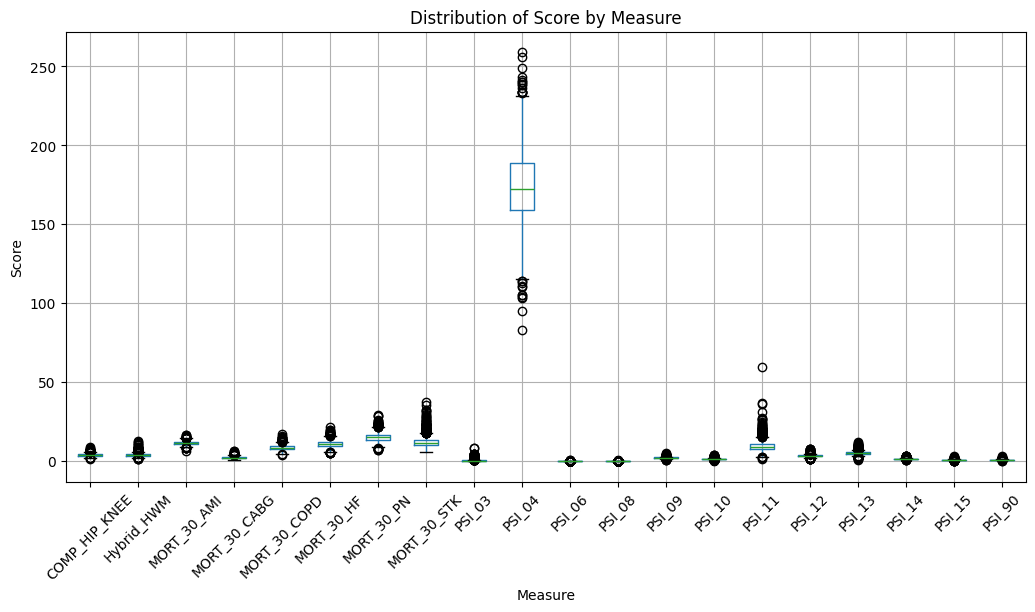

In [91]:
DCH_clean.boxplot(column='Score', by='Measure ID', figsize=(12, 6))

plt.title('Distribution of Score by Measure')
plt.suptitle('')
plt.xlabel('Measure')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.show()

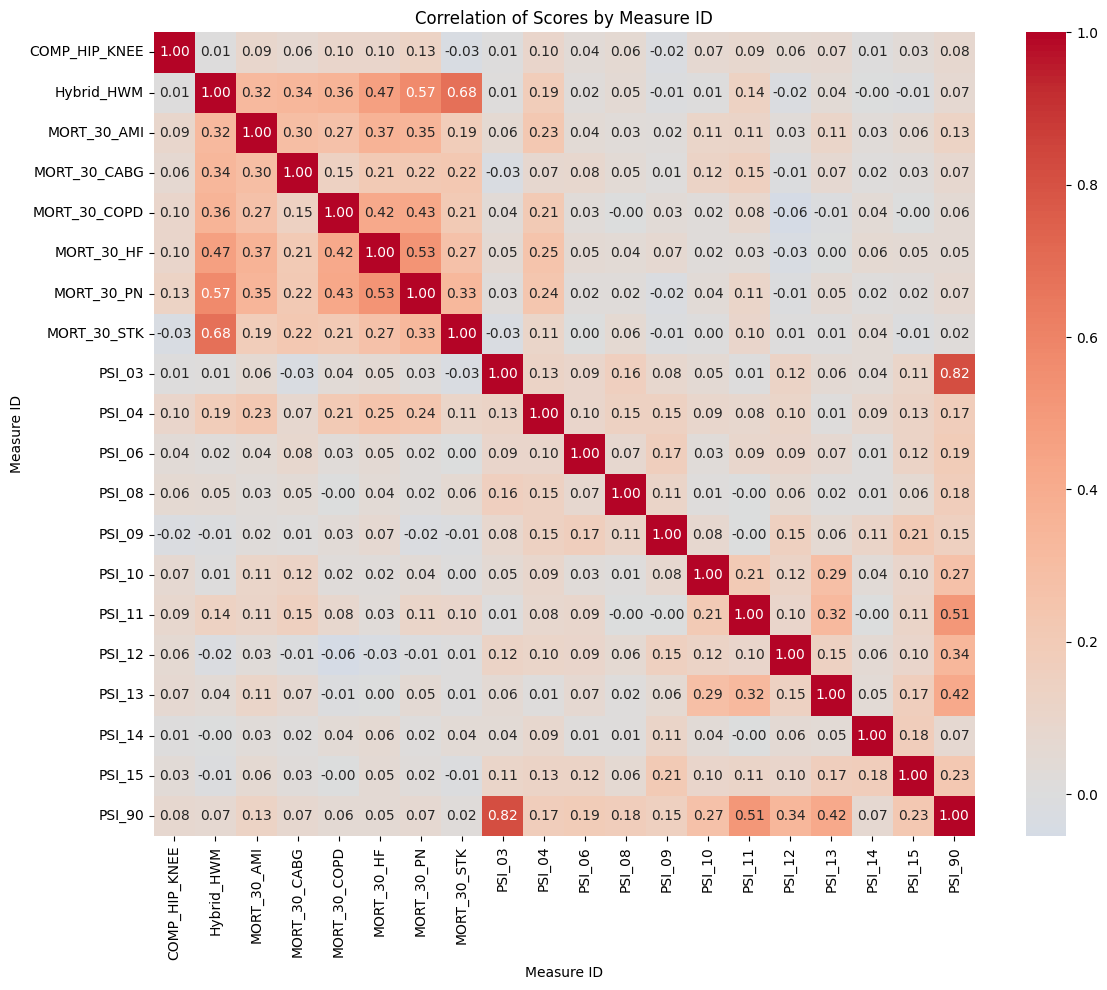

In [92]:
DCH_score_by_measure = DCH_clean.pivot_table(
    index='Facility ID',
    columns='Measure ID',
    values='Score',
    aggfunc='mean'
)

# Calculate correlations between Measure IDs
correlation = DCH_score_by_measure.corr()

# Create heat map
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation of Scores by Measure ID')
plt.xlabel('Measure ID')
plt.ylabel('Measure ID')
plt.tight_layout()
plt.show()

In [93]:
DCH_score_by_measure

Measure ID,COMP_HIP_KNEE,Hybrid_HWM,MORT_30_AMI,MORT_30_CABG,MORT_30_COPD,MORT_30_HF,MORT_30_PN,MORT_30_STK,PSI_03,PSI_04,PSI_06,PSI_08,PSI_09,PSI_10,PSI_11,PSI_12,PSI_13,PSI_14,PSI_15,PSI_90
Facility ID,,,,,,,,,,,,,,,,,,,,
010001,3.8,4.4,13.5,3.2,9.1,10.4,16.9,13.1,0.13,203.00,0.13,0.34,2.75,1.32,10.66,4.40,5.40,1.58,2.09,0.95
010005,5.0,5.7,NaN,NaN,10.3,12.1,20.4,15.2,0.33,184.79,0.19,0.25,2.04,1.44,8.65,4.89,6.38,1.73,1.23,0.97
010006,4.8,5.1,13.7,5.3,7.0,13.0,19.3,17.3,0.55,236.12,0.26,0.25,3.59,1.44,16.59,2.92,4.62,1.96,1.34,1.14
010007,NaN,6.7,NaN,NaN,9.0,13.4,21.4,NaN,0.54,NaN,0.21,0.27,2.32,1.65,11.82,3.41,NaN,NaN,1.05,1.06
010011,NaN,4.3,12.3,2.1,10.9,13.0,16.5,10.4,0.23,176.90,0.34,0.28,1.95,1.86,13.64,2.70,6.78,1.72,0.96,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670333,NaN,3.6,NaN,NaN,NaN,NaN,14.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
670335,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
670340,NaN,3.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# Count missing measures for each facility
missing_per_facility = DCH_score_by_measure.isna().sum(axis=1)

# Count how many facilities have each number of missing measures
facilities_by_missing = missing_per_facility.value_counts().sort_index()

print(facilities_by_missing)
# 20 total measures in the Complications & Death dataset
# 8% of faciliites in the dataset only have 1 reported measure

0     651
1     571
2     388
3     307
4     181
5     114
6     107
7     150
8     130
9     123
10     62
11     40
12     34
13     50
14     72
15    127
16    197
17    238
18    418
19    346
Name: count, dtype: int64


In [95]:
missing_by_measure = DCH_score_by_measure.isna().sum().sort_values(ascending=False)
print(missing_by_measure)

Measure ID
MORT_30_CABG     3445
PSI_04           2785
COMP_HIP_KNEE    2600
MORT_30_AMI      2371
PSI_13           1900
MORT_30_STK      1884
PSI_10           1854
PSI_11           1845
PSI_14           1832
MORT_30_COPD     1683
PSI_15           1516
PSI_09           1480
PSI_12           1473
PSI_90           1398
MORT_30_HF       1257
PSI_03           1250
PSI_08           1222
PSI_06           1221
MORT_30_PN        667
Hybrid_HWM         45
dtype: int64


### Complications and Deaths - State Data Inspection and Cleaning

In [96]:
death_comp_state.head()

,State,Measure ID,Measure Name,Number of Hospitals Worse,Number of Hospitals Same,Number of Hospitals Better,Number of Hospitals Too Few,Footnote,Start Date,End Date
0,AK,COMP_HIP_KNEE,Rate of complications for hip/knee replacement...,0,4,0,5,NaN,04/01/2023,03/31/2025
1,AK,Hybrid_HWM,Hybrid Hospital-Wide All-Cause Risk Standardiz...,0,16,1,4,NaN,07/01/2024,06/30/2025
2,AK,MORT_30_AMI,Death rate for heart attack patients,0,5,0,11,NaN,07/01/2022,06/30/2025
3,AK,MORT_30_CABG,Death rate for CABG surgery patients,0,2,0,1,NaN,07/01/2022,06/30/2025
4,AK,MORT_30_COPD,Death rate for COPD patients,1,9,0,11,NaN,07/01/2022,06/30/2025


In [97]:
print(death_comp_state["Number of Hospitals Worse"].unique());
print(death_comp_state["Number of Hospitals Same"].unique());
print(death_comp_state["Number of Hospitals Better"].unique());
print(death_comp_state["Number of Hospitals Too Few"].unique());
print(death_comp_state["Footnote"].unique());

['0' '1' '2' '36' '4' '14' '7' '3' '5' '20' '6' 'Not Available' '27' '8'
 '19' '9' '12' '15' '10' '16' '17' '11' '23' '45']
['4' '16' '5' '2' '9' '8' '14' '6' '7' '34' '48' '29' '18' '49' '50' '58'
 '35' '77' '24' '82' '54' '36' '33' '41' '53' '57' '12' '25' '10' '43'
 '19' '20' '47' '31' '28' '30' '37' 'Not Available' '65' '39' '45' '60'
 '67' '68' '55' '59' '180' '228' '158' '214' '215' '242' '217' '273' '137'
 '287' '288' '277' '230' '227' '269' '222' '241' '274' '267' '13' '23'
 '52' '51' '15' '26' '27' '3' '1' '119' '136' '144' '64' '163' '162' '168'
 '105' '175' '170' '153' '146' '165' '148' '160' '42' '87' '81' '93' '62'
 '100' '83' '66' '84' '71' '80' '11' '97' '92' '32' '134' '86' '123' '120'
 '145' '91' '113' '61' '108' '94' '104' '90' '98' '112' '38' '74' '102'
 '78' '70' '76' '79' '44' '73' '63' '40' '17' '85' '22' '46' '21' '106'
 '89' '72' '103' '56' '99' '88' '117' '121' '143' '69' '139' '128' '110'
 '126' '107' '116' '129' '114' '118' '101' '75' '111' '127' '109' '142'


In [98]:
print(death_comp_state[death_comp_state['Footnote'].notna()])
print(death_comp_state["Number of Hospitals Worse"][death_comp_state['Footnote'].notna()].unique())

     State     Measure ID                                       Measure Name  \
60      AS  COMP_HIP_KNEE  Rate of complications for hip/knee replacement...   
61      AS     Hybrid_HWM  Hybrid Hospital-Wide All-Cause Risk Standardiz...   
62      AS    MORT_30_AMI               Death rate for heart attack patients   
63      AS   MORT_30_CABG               Death rate for CABG surgery patients   
64      AS   MORT_30_COPD                       Death rate for COPD patients   
...    ...            ...                                                ...   
1015    VI         PSI_12  Perioperative pulmonary embolism or deep vein ...   
1016    VI         PSI_13                          Postoperative sepsis rate   
1017    VI         PSI_14                Postoperative wound dehiscence rate   
1018    VI         PSI_15  Abdominopelvic accidental puncture or lacerati...   
1019    VI         PSI_90  CMS Medicare PSI 90: Patient safety and advers...   

     Number of Hospitals Worse Number o

In [99]:
DCS_clean = death_comp_state[death_comp_state['Footnote'].isna()].copy()
DCS_clean['Number of Hospitals Worse'] = DCS_clean['Number of Hospitals Worse'].astype(float)
DCS_clean['Number of Hospitals Same'] = DCS_clean['Number of Hospitals Same'].astype(float)
DCS_clean['Number of Hospitals Better'] = DCS_clean['Number of Hospitals Better'].astype(float)

Measure Summary:


,Avg_Better,Avg_Same,Avg_Worse,Avg_Net_Performance
Measure ID,,,,
MORT_30_HF,2.486969,95.853402,1.659630,0.827339
MORT_30_STK,3.075055,94.465518,2.459427,0.615629
MORT_30_PN,2.457894,95.436924,2.105182,0.352713
Hybrid_HWM,9.381407,81.270985,9.347607,0.033800
MORT_30_AMI,0.163899,99.676732,0.159370,0.004529
MORT_30_COPD,0.483456,98.911520,0.605024,-0.121568
COMP_HIP_KNEE,0.229297,99.399092,0.371611,-0.142314
PSI_14,0.000000,99.710259,0.289741,-0.289741
PSI_08,0.013835,99.667926,0.318238,-0.304403


State Summary:


,Avg_Better,Avg_Same,Avg_Worse,Avg_Net_Performance
State,,,,
CT,5.654285,93.065289,1.280425,4.373860
CA,3.457013,94.982701,1.560286,1.896727
DC,7.500000,86.547619,5.952381,1.547619
NJ,2.331445,96.420409,1.248145,1.083300
MN,1.634377,97.771962,0.593661,1.040717
RI,1.010101,98.989899,0.000000,1.010101
SD,1.503934,97.945561,0.550505,0.953429
TX,2.028872,96.800720,1.170408,0.858464
FL,2.528771,95.663470,1.807758,0.721013


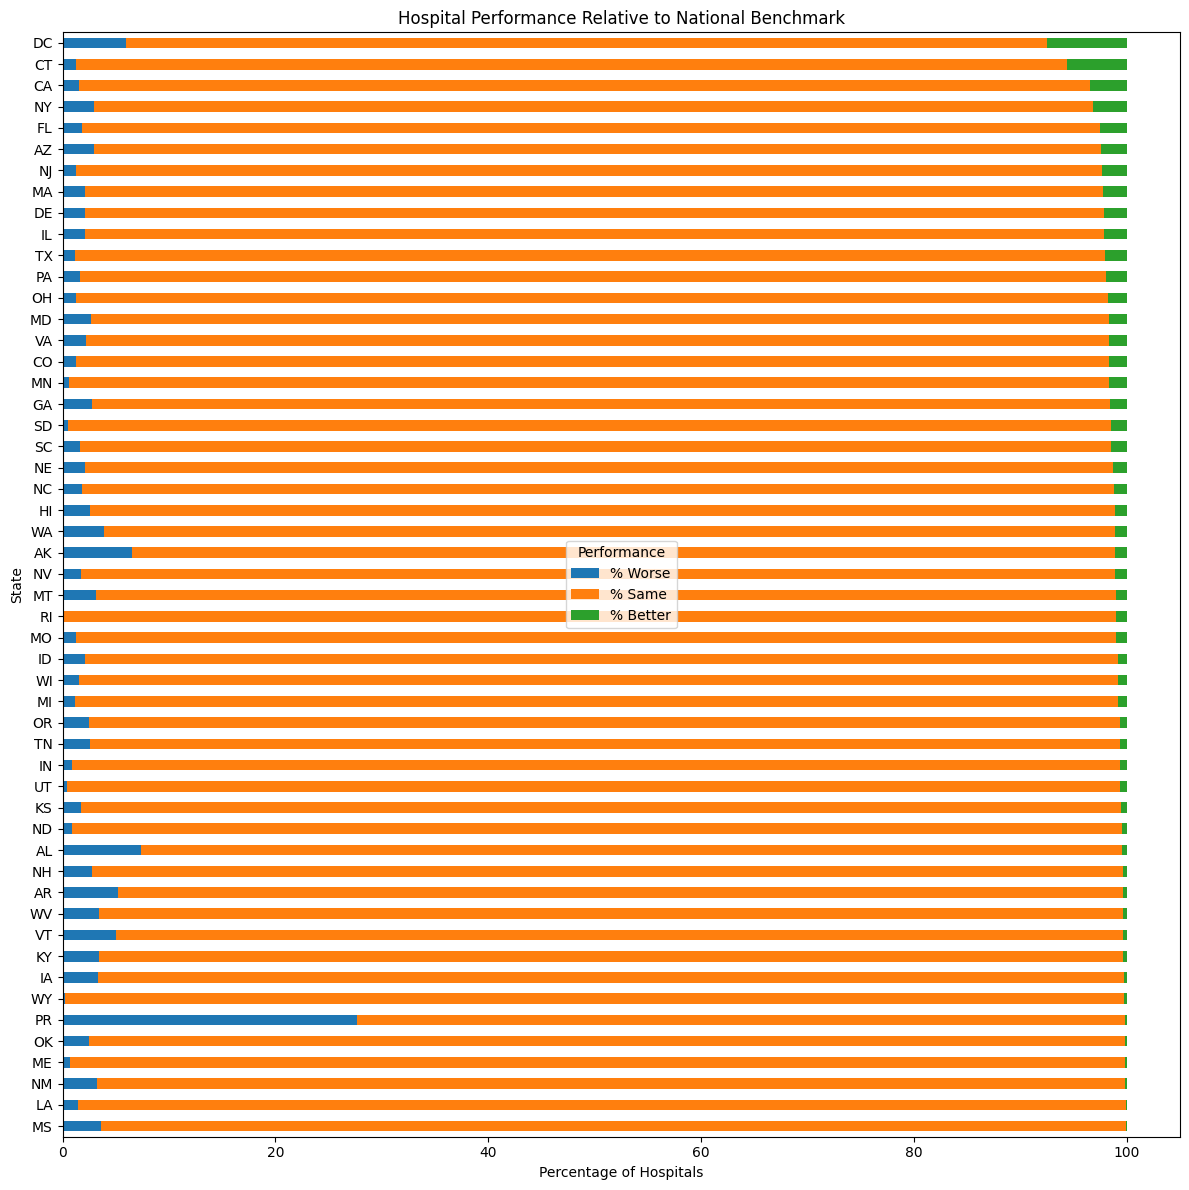

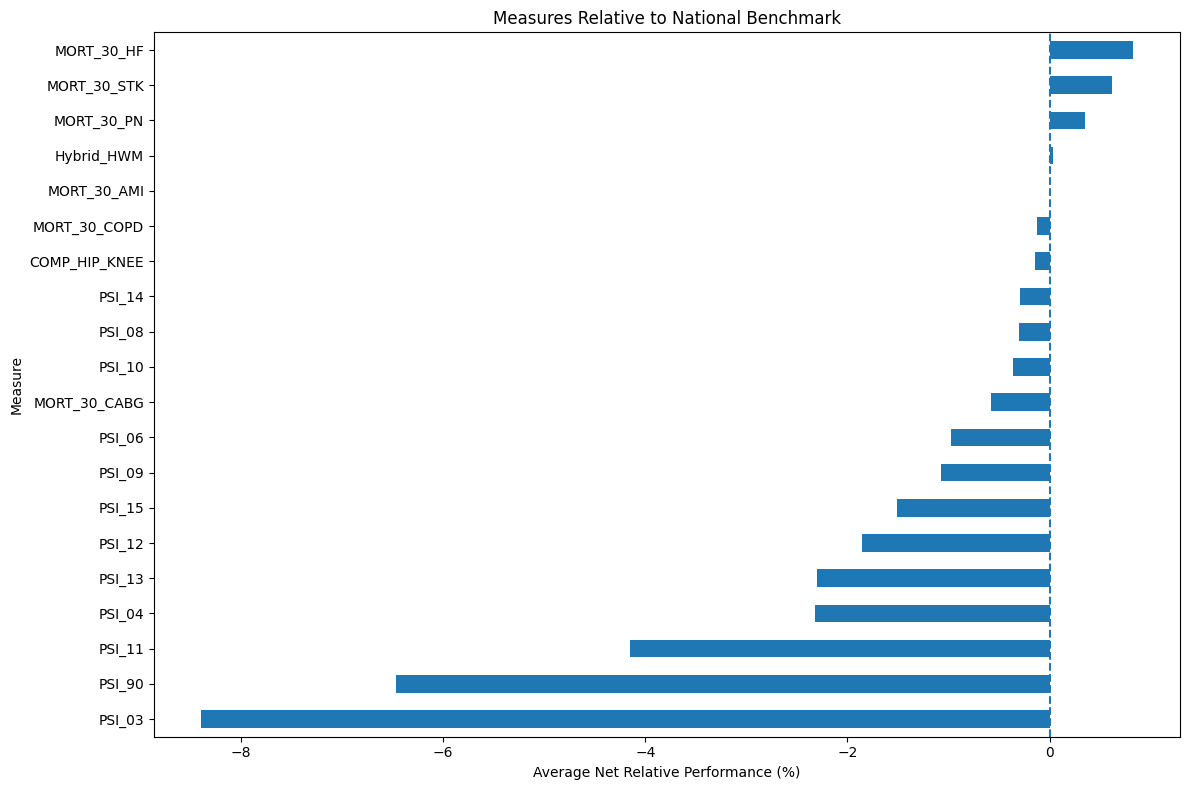

Top 10 States:


,Avg_Better,Avg_Same,Avg_Worse,Avg_Net_Performance
State,,,,
CT,5.654285,93.065289,1.280425,4.373860
CA,3.457013,94.982701,1.560286,1.896727
DC,7.500000,86.547619,5.952381,1.547619
NJ,2.331445,96.420409,1.248145,1.083300
MN,1.634377,97.771962,0.593661,1.040717
RI,1.010101,98.989899,0.000000,1.010101
SD,1.503934,97.945561,0.550505,0.953429
TX,2.028872,96.800720,1.170408,0.858464
FL,2.528771,95.663470,1.807758,0.721013


Bottom 10 States:


,Avg_Better,Avg_Same,Avg_Worse,Avg_Net_Performance
State,,,,
IA,0.295219,96.368646,3.336135,-3.040916
WV,0.358852,96.237309,3.403840,-3.044988
KY,0.327281,96.239920,3.432799,-3.105518
NM,0.128205,96.591411,3.280384,-3.152178
MS,0.063291,96.305410,3.631299,-3.568008
VT,0.333333,94.663004,5.003663,-4.670330
AR,0.376956,94.388640,5.234404,-4.857448
AK,1.127451,92.354692,6.517857,-5.390406
AL,0.418619,92.170497,7.410884,-6.992265


In [100]:
# Calculate percentages

DCS_clean['Total Hospitals'] = (
    DCS_clean['Number of Hospitals Worse'] +
    DCS_clean['Number of Hospitals Same'] +
    DCS_clean['Number of Hospitals Better']
)

DCS_clean['% Worse'] = (
    DCS_clean['Number of Hospitals Worse'] /
    DCS_clean['Total Hospitals'] * 100
)

DCS_clean['% Same'] = (
    DCS_clean['Number of Hospitals Same'] /
    DCS_clean['Total Hospitals'] * 100
)

DCS_clean['% Better'] = (
    DCS_clean['Number of Hospitals Better'] /
    DCS_clean['Total Hospitals'] * 100
)

# Net relative performance:
# Positive = more hospitals are better than the national score
# Negative = more hospitals are worse than the national score
DCS_clean['Net Relative Performance'] = (
    DCS_clean['% Better'] - DCS_clean['% Worse']
)


# Summary by Measure
measure_summary = (
    DCS_clean.groupby('Measure ID')
    .agg(
        Avg_Better=('% Better', 'mean'),
        Avg_Same=('% Same', 'mean'),
        Avg_Worse=('% Worse', 'mean'),
        Avg_Net_Performance=('Net Relative Performance', 'mean')
    )
    .sort_values('Avg_Net_Performance', ascending=False)
)

print("Measure Summary:")
display(measure_summary)


# Summary by State
state_summary = (
    DCS_clean.groupby('State')
    .agg(
        Avg_Better=('% Better', 'mean'),
        Avg_Same=('% Same', 'mean'),
        Avg_Worse=('% Worse', 'mean'),
        Avg_Net_Performance=('Net Relative Performance', 'mean')
    )
    .sort_values('Avg_Net_Performance', ascending=False)
)

print("State Summary:")
display(state_summary)

# State Percentages Stacked Bar Chart
state_percentages = (
    DCS_clean.groupby('State')[['% Worse', '% Same', '% Better']]
    .mean()
    .sort_values('% Better')
)

state_percentages.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 12)
)

plt.xlabel('Percentage of Hospitals')
plt.ylabel('State')
plt.title('Hospital Performance Relative to National Benchmark')
plt.legend(title='Performance')
plt.tight_layout()
plt.show()


# Ranked Bar Chart: Measures
plt.figure(figsize=(12, 8))

measure_summary['Avg_Net_Performance'].sort_values().plot(
    kind='barh'
)

plt.axvline(0, linestyle='--')
plt.xlabel('Average Net Relative Performance (%)')
plt.ylabel('Measure')
plt.title('Measures Relative to National Benchmark')
plt.tight_layout()
plt.show()

# Top and Bottom States
print("Top 10 States:")
display(state_summary.head(10))

print("Bottom 10 States:")
display(state_summary.tail(10))

## Initial Data Analysis (Ambulatory Surgical Center Data)

In [101]:
ASC_facility = pd.read_csv("Data/ASC_Facility.csv")
ASC_state = pd.read_csv("Data/ASC_State.csv")

In [102]:
cols = ['ASC-1 Rate*', 'ASC-1 Footnote', 'ASC-2 Rate*',
        'ASC-2 Footnote', 'ASC-3 Rate*', 'ASC-3 Footnote', 'ASC-4 Rate*',
        'ASC-4 Footnote', 'ASC-9 Rate*', 'ASC-9 Footnote', 'ASC-11 Rate*',
        'ASC-11 Footnote', 'ASC-12 Total Cases', 'ASC-12 Performance Category',
        'ASC-12 RSHV Rate', 'ASC-12 Interval Lower Limit',
        'ASC-12 Interval Upper Limit', 'ASC-12 Footnote', 'ASC-13 Rate*',
        'ASC-13 Footnote', 'ASC-14 Rate*', 'ASC-14 Footnote',
        'ASC-17 Total Cases', 'ASC-17 Performance Category', 'ASC-17 RSHV Rate',
        'ASC-17 Interval Lower Limit', 'ASC-17 Interval Upper Limit',
        'ASC-17 Footnote', 'ASC-18 Total Cases', 'ASC-18 Performance Category',
        'ASC-18 RSHV Rate', 'ASC-18 Interval Lower Limit',
        'ASC-18 Interval Upper Limit', 'ASC-18 Footnote', 'ASC-19 Total Cases',
        'ASC-19 Performance Category', 'ASC-19 RSHV Rate',
        'ASC-19 Interval Lower Limit', 'ASC-19 Interval Upper Limit', 'ASC-19 Footnote']

all_nan_rows = ASC_facility[ASC_facility[cols].isna().all(axis=1)]
print(all_nan_rows)

Empty DataFrame
Columns: [Facility Name, Facility ID, NPI, City/Town, State, ZIP Code, Year, ASC-1 Rate*, ASC-1 Footnote, ASC-2 Rate*, ASC-2 Footnote, ASC-3 Rate*, ASC-3 Footnote, ASC-4 Rate*, ASC-4 Footnote, ASC-9 Rate*, ASC-9 Footnote, ASC-11 Rate*, ASC-11 Footnote, ASC-12 Total Cases, ASC-12 Performance Category, ASC-12 RSHV Rate, ASC-12 Interval Lower Limit, ASC-12 Interval Upper Limit, ASC-12 Footnote, ASC-13 Rate*, ASC-13 Footnote, ASC-14 Rate*, ASC-14 Footnote, ASC-17 Total Cases, ASC-17 Performance Category, ASC-17 RSHV Rate, ASC-17 Interval Lower Limit, ASC-17 Interval Upper Limit, ASC-17 Footnote, ASC-18 Total Cases, ASC-18 Performance Category, ASC-18 RSHV Rate, ASC-18 Interval Lower Limit, ASC-18 Interval Upper Limit, ASC-18 Footnote, ASC-19 Total Cases, ASC-19 Performance Category, ASC-19 RSHV Rate, ASC-19 Interval Lower Limit, ASC-19 Interval Upper Limit, ASC-19 Footnote]
Index: []

[0 rows x 47 columns]


In [103]:
ASC_state.head()

,State,Year,Avg ASC-1 State Rate*,Median ASC-1 State Rate*,Avg ASC-2 State Rate*,Median ASC-2 State Rate*,Avg ASC-3 State Rate*,Median ASC-3 State Rate*,Avg ASC-4 State Rate*,Median ASC-4 State Rate*,...,ASC-17 Worse,ASC-17 Too Small,ASC-18 Better,ASC-18 No Different,ASC-18 Worse,ASC-18 Too Small,ASC-19 Better,ASC-19 No Different,ASC-19 Worse,ASC-19 Too Small
0,SC,2024,0.000,0.000,0.012,0.000,0.003,0.000,0.067,0.050,...,0,9,1,10,1,5,0,21,0,28
1,AZ,2024,0.002,0.000,0.013,0.000,0.007,0.000,0.094,0.067,...,2,49,0,17,1,17,0,47,1,76
2,LA,2024,0.001,0.000,0.021,0.008,0.004,0.000,0.085,0.055,...,0,20,0,2,0,7,0,19,0,31
3,MN,2024,0.001,0.000,0.020,0.000,0.003,0.000,0.103,0.062,...,2,24,0,9,0,9,0,18,0,44
4,NJ,2024,0.001,0.000,0.019,0.015,0.003,0.000,0.078,0.063,...,0,58,1,30,0,11,0,46,0,104


In [104]:
cols = ['Avg ASC-1 State Rate*', 'Median ASC-1 State Rate*',
       'Avg ASC-2 State Rate*', 'Median ASC-2 State Rate*',
       'Avg ASC-3 State Rate*', 'Median ASC-3 State Rate*',
       'Avg ASC-4 State Rate*', 'Median ASC-4 State Rate*',
       'Avg ASC-9 State Rate*', 'Median ASC-9 State Rate*',
       'Avg ASC-11 State Rate*', 'Median ASC-11 State Rate*', 'ASC-12 Better',
       'ASC-12 No Different', 'ASC-12 Worse', 'ASC-12 Too Small',
       'Avg ASC-13 State Rate*', 'Median ASC-13 State Rate*',
       'Avg ASC-14 State Rate*', 'Median ASC-14 State Rate*', 'ASC-17 Better',
       'ASC-17 No Different', 'ASC-17 Worse', 'ASC-17 Too Small',
       'ASC-18 Better', 'ASC-18 No Different', 'ASC-18 Worse',
       'ASC-18 Too Small', 'ASC-19 Better', 'ASC-19 No Different',
       'ASC-19 Worse', 'ASC-19 Too Small']
all_nan_rows = ASC_state[ASC_state[cols].isna().all(axis=1)]
print(all_nan_rows)

Empty DataFrame
Columns: [State, Year, Avg ASC-1 State Rate*, Median ASC-1 State Rate*, Avg ASC-2 State Rate*, Median ASC-2 State Rate*, Avg ASC-3 State Rate*, Median ASC-3 State Rate*, Avg ASC-4 State Rate*, Median ASC-4 State Rate*, Avg ASC-9 State Rate*, Median ASC-9 State Rate*, Avg ASC-11 State Rate*, Median ASC-11 State Rate*, ASC-12 Better, ASC-12 No Different, ASC-12 Worse, ASC-12 Too Small, Avg ASC-13 State Rate*, Median ASC-13 State Rate*, Avg ASC-14 State Rate*, Median ASC-14 State Rate*, ASC-17 Better, ASC-17 No Different, ASC-17 Worse, ASC-17 Too Small, ASC-18 Better, ASC-18 No Different, ASC-18 Worse, ASC-18 Too Small, ASC-19 Better, ASC-19 No Different, ASC-19 Worse, ASC-19 Too Small]
Index: []

[0 rows x 34 columns]


In [105]:
facility_col = "Facility ID"

# Number of rows per facility in each dataset
dch_counts = DCH_clean.groupby(facility_col).size().rename("DCH_rows")
tch_counts = TCH_clean.groupby(facility_col).size().rename("TCH_rows")
asc_counts = ASC_facility.groupby(facility_col).size().rename("ASC_rows")

# Find facilities that appear in BOTH DCH and TCH
common_facilities = (
    DCH_clean[[facility_col]]
    .drop_duplicates()
    .merge(
        TCH_clean[[facility_col]].drop_duplicates(),
        on=facility_col,
        how="inner"
    )
)

# Add row counts from each dataset
facility_check = (
    common_facilities
    .merge(dch_counts, on=facility_col, how="left")
    .merge(tch_counts, on=facility_col, how="left")
    .merge(asc_counts, on=facility_col, how="left")
)

# Check whether each common DCH/TCH facility is also in ASC
facility_check["In_ASC"] = facility_check["ASC_rows"].notna()

print("Facility overlap summary")
print("-" * 24)
print(f"DCH facilities: {DCH_clean[facility_col].nunique()}")
print(f"TCH facilities: {TCH_clean[facility_col].nunique()}")
print(f"Common DCH/TCH facilities: {len(common_facilities)}")
print(f"Common facilities also in ASC: {facility_check['In_ASC'].sum()}")

print("\nFacility-level breakdown (first 10 rows):")
display(facility_check.head(10))

Facility overlap summary
------------------------
DCH facilities: 4306
TCH facilities: 4440
Common DCH/TCH facilities: 3959
Common facilities also in ASC: 0

Facility-level breakdown (first 10 rows):


,Facility ID,DCH_rows,TCH_rows,ASC_rows,In_ASC
0,010001,20,15,NaN,False
1,010005,18,16,NaN,False
2,010006,20,19,NaN,False
3,010007,13,13,NaN,False
4,010011,19,14,NaN,False
5,010012,17,15,NaN,False
6,010016,20,15,NaN,False
7,010019,14,15,NaN,False
8,010021,10,15,NaN,False
9,010022,5,10,NaN,False


### Some More Summaries and Plots

In [106]:
coverage_datasets = {
    "DCH hospitals": DCH_clean,
    "TCH hospitals": TCH_clean,
    "DCH states": DCS_clean,
    "TCH states": TCS_clean,
    "ASC facilities": ASC_facility,
    "ASC states": ASC_state,
}

def coverage_row(name, df):
    return {
        "Dataset": name,
        "Rows": len(df),
        "Facilities": (
            df["Facility ID"].nunique()
            if "Facility ID" in df.columns else None
        ),
        "States": (
            df["State"].nunique()
            if "State" in df.columns else None
        ),
        "Measures": (
            df["Measure ID"].nunique()
            if "Measure ID" in df.columns else None
        ),
    }

coverage_summary = pd.DataFrame(
    [coverage_row(name, df) for name, df in coverage_datasets.items()]
).set_index("Dataset")

display(coverage_summary)

,Rows,Facilities,States,Measures
Dataset,,,,
DCH hospitals,52392,4306.0,55,20.0
TCH hospitals,57043,4440.0,54,25.0
DCH states,1040,NaN,52,20.0
TCH states,1518,NaN,52,31.0
ASC facilities,5711,5611.0,54,NaN
ASC states,54,NaN,54,NaN


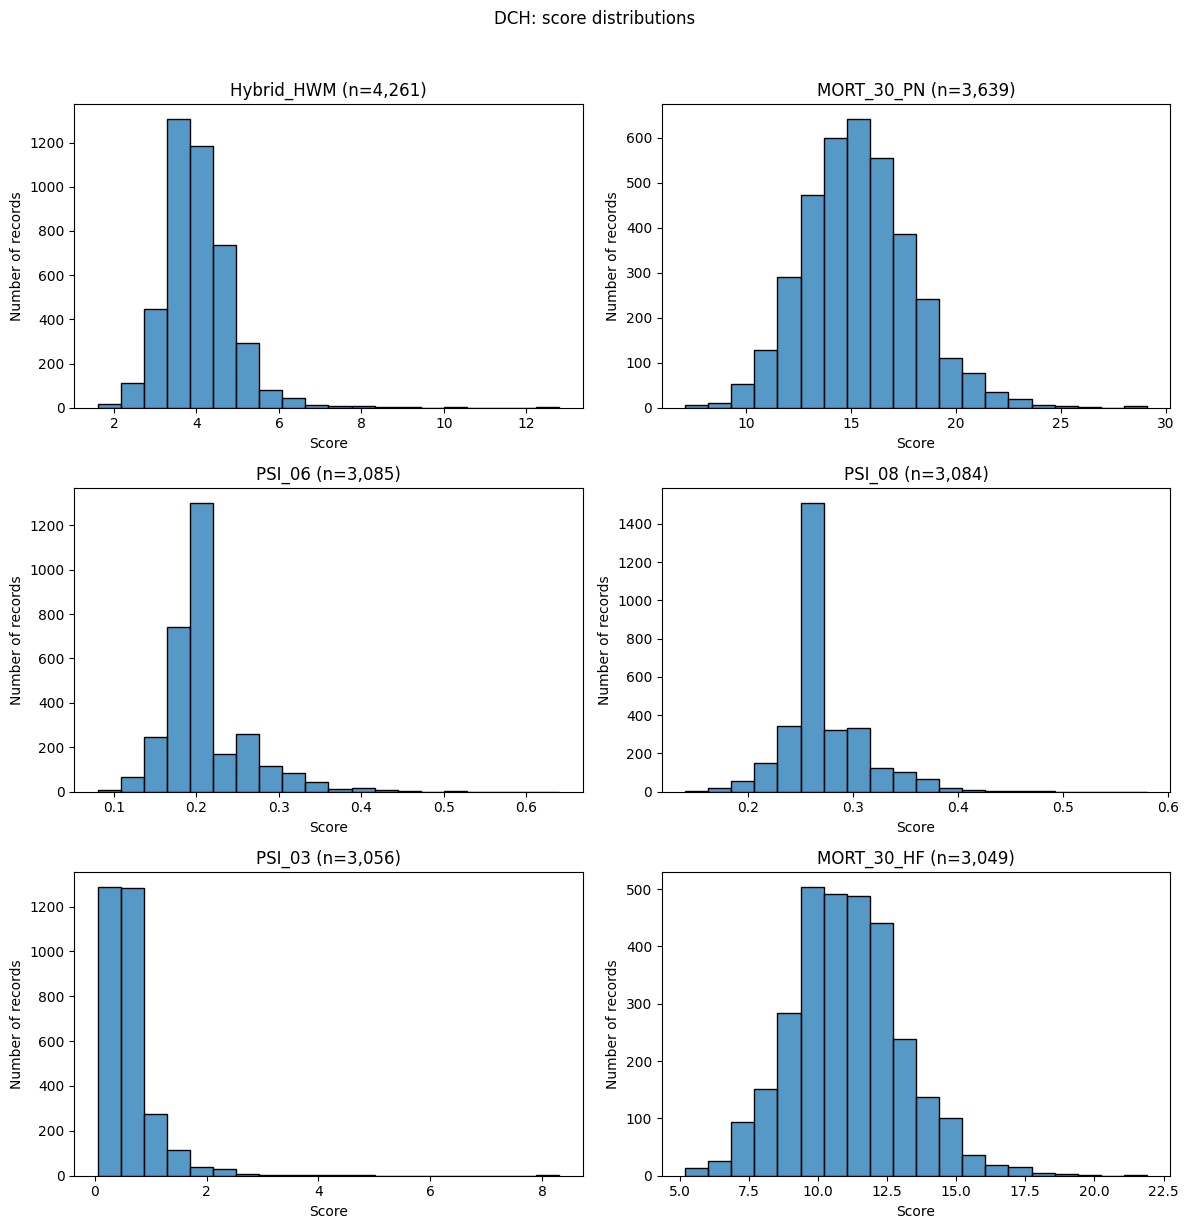

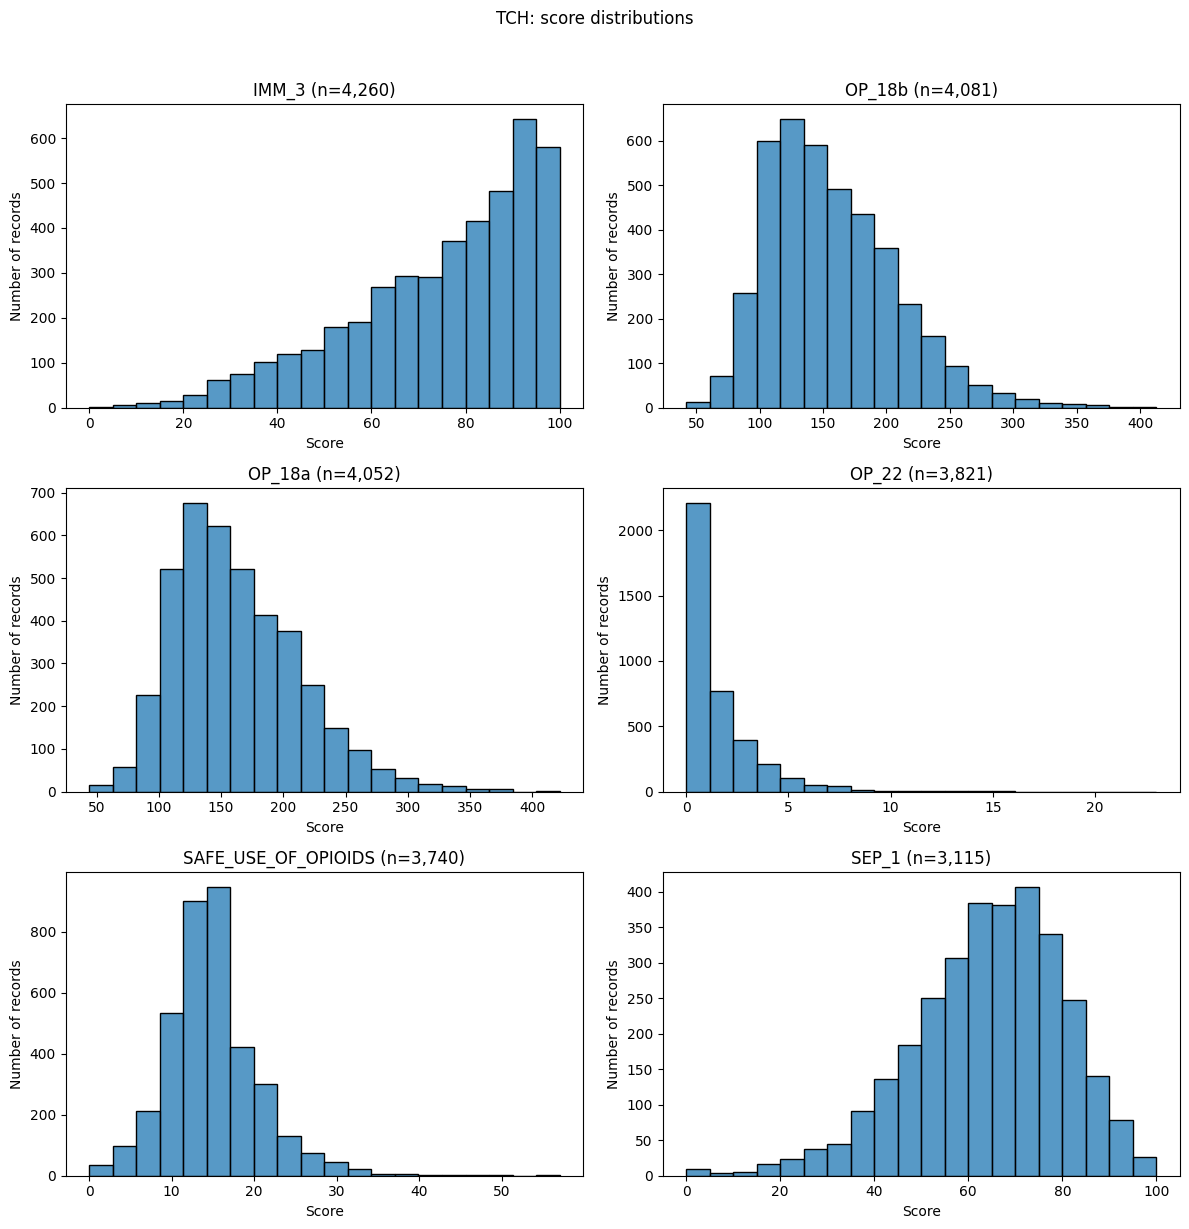

In [107]:
def plot_measure_distributions(df, dataset_name, max_measures=6):
    data = df.copy()
    data["Score_numeric"] = pd.to_numeric(data["Score"], errors="coerce")
    data = data.dropna(subset=["Measure ID", "Score_numeric"])

    top_measures = data["Measure ID"].value_counts().head(max_measures).index
    ncols = 2
    nrows = int(np.ceil(len(top_measures) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, 4 * nrows),
        squeeze=False
    )
    axes = axes.flatten()

    for ax, measure_id in zip(axes, top_measures):
        scores = data.loc[
            data["Measure ID"] == measure_id, "Score_numeric"
        ]
        sns.histplot(scores, bins=20, ax=ax)
        ax.set_title(f"{measure_id} (n={len(scores):,})")
        ax.set_xlabel("Score")
        ax.set_ylabel("Number of records")

    for ax in axes[len(top_measures):]:
        ax.set_visible(False)

    fig.suptitle(f"{dataset_name}: score distributions", y=1.02)
    plt.tight_layout()
    plt.show()

plot_measure_distributions(DCH_clean, "DCH")
plot_measure_distributions(TCH_clean, "TCH")

In [109]:
DCS_clean["Measure ID"].value_counts().head(10)

Measure ID
COMP_HIP_KNEE    52
Hybrid_HWM       52
MORT_30_AMI      52
MORT_30_CABG     52
MORT_30_COPD     52
MORT_30_HF       52
MORT_30_PN       52
MORT_30_STK      52
PSI_03           52
PSI_04           52
Name: count, dtype: int64

In [110]:
measure_id = "COMP_HIP_KNEE"

dch_map_data = (
    DCS_clean.loc[DCS_clean["Measure ID"] == measure_id]
    .groupby("State", as_index=False)["% Better"]
    .mean()
)

fig = px.choropleth(
    dch_map_data,
    locations="State",
    locationmode="USA-states",
    color="% Better",
    scope="usa",
    color_continuous_scale="Viridis",
    labels={"% Better": "Hospitals rated better (%)"},
    title=f"DCH: hospitals rated better by state — {measure_id}",
)
fig.show()

In [111]:
TCS_clean["Measure ID"].value_counts().head(10)

Measure ID
IMM_3          52
OP_18a         52
OP_18b         52
OP_18d         52
OP_18c         52
OP_22          52
SEV_SEP_6HR    52
SEP_SH_6HR     52
SEV_SEP_3HR    52
SEP_SH_3HR     52
Name: count, dtype: int64

In [112]:
measure_id = "IMM_3"

tch_map_data = (
    TCS_clean.loc[TCS_clean["Measure ID"] == measure_id]
    .groupby("State", as_index=False)["Score"]
    .mean()
)

fig = px.choropleth(
    tch_map_data,
    locations="State",
    locationmode="USA-states",
    color="Score",
    scope="usa",
    color_continuous_scale="Viridis",
    labels={"Score": "Average score"},
    title=f"TCH: average state score — {measure_id}",
)
fig.show()